In [34]:
import pandas as pd
import numpy as np

link="https://raw.githubusercontent.com/tikisen/6306-case-study-1/master/Beers.csv"


In [35]:
df = pd.read_csv(link)
df.head(20)

,Name,Beer_ID,ABV,IBU,Brewery_id,Style,Ounces
0,Pub Beer,1436,0.050,NaN,409,American Pale Lager,12.0
1,Devil's Cup,2265,0.066,NaN,178,American Pale Ale (APA),12.0
2,Rise of the Phoenix,2264,0.071,NaN,178,American IPA,12.0
3,Sinister,2263,0.090,NaN,178,American Double / Imperial IPA,12.0
4,Sex and Candy,2262,0.075,NaN,178,American IPA,12.0
5,Black Exodus,2261,0.077,NaN,178,Oatmeal Stout,12.0
6,Lake Street Express,2260,0.045,NaN,178,American Pale Ale (APA),12.0
7,Foreman,2259,0.065,NaN,178,American Porter,12.0
8,Jade,2258,0.055,NaN,178,American Pale Ale (APA),12.0
9,Cone Crusher,2131,0.086,NaN,178,American Double / Imperial IPA,12.0


In [36]:
df.describe()

,Beer_ID,ABV,IBU,Brewery_id,Ounces
count,2410.000000,2348.000000,1405.000000,2410.000000,2410.000000
mean,1431.113278,0.059773,42.713167,232.749793,13.592241
std,752.459975,0.013542,25.954066,157.685604,2.352204
min,1.000000,0.001000,4.000000,1.000000,8.400000
25%,808.250000,0.050000,21.000000,94.000000,12.000000
50%,1453.500000,0.056000,35.000000,206.000000,12.000000
75%,2075.750000,0.067000,64.000000,367.000000,16.000000
max,2692.000000,0.128000,138.000000,558.000000,32.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        2410 non-null   object 
 1   Beer_ID     2410 non-null   int64  
 2   ABV         2348 non-null   float64
 3   IBU         1405 non-null   float64
 4   Brewery_id  2410 non-null   int64  
 5   Style       2405 non-null   object 
 6   Ounces      2410 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 131.9+ KB


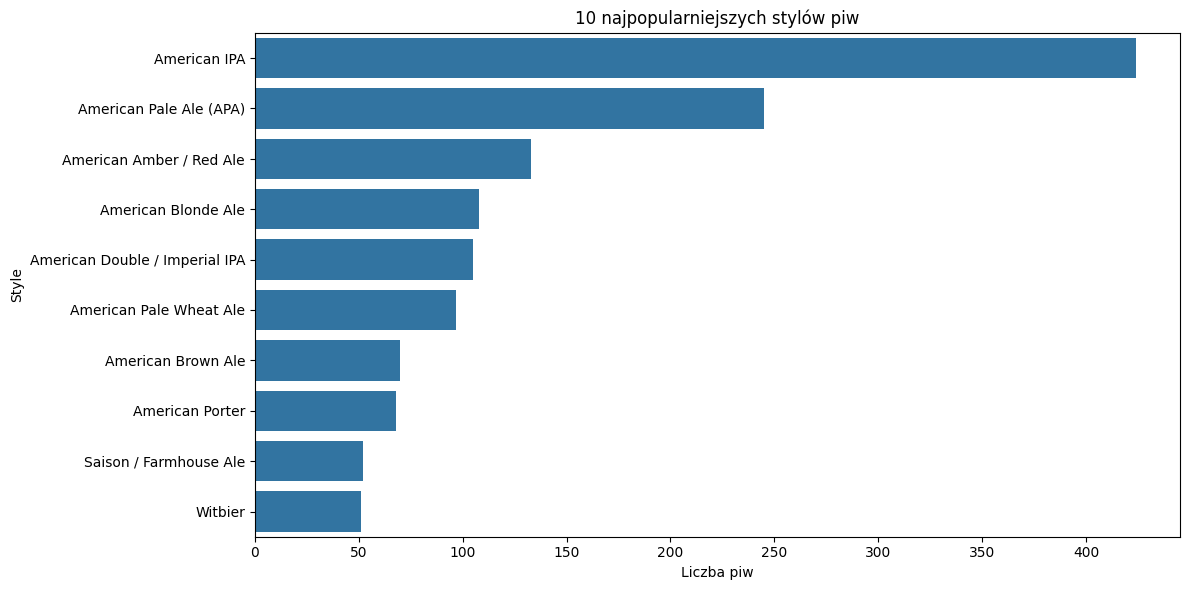

In [54]:
# Top 10 najpopularniejszych stylów piw
plt.figure(figsize=(12, 6))
top_styles = df['Style'].value_counts().head(10)
sns.barplot(x=top_styles.values, y=top_styles.index)
plt.title('10 najpopularniejszych stylów piw')
plt.xlabel('Liczba piw')
plt.tight_layout()
plt.show()

In [38]:
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [46]:
df1 = df.copy()
le = LabelEncoder()
type_encoded = le.fit_transform(df1["Style"])
df1["Style_nb"] = type_encoded
df1 = df1.drop(columns="Style")
df1 = df1.dropna()

df1.head(10)

,Name,Beer_ID,ABV,IBU,Brewery_id,Ounces,Style_nb
14,Bitter Bitch,1979,0.061,60.0,178,12.0,16
21,Lower De Boom,1036,0.099,92.0,369,8.4,5
22,Fireside Chat,1024,0.079,45.0,369,12.0,97
24,Bitter American,876,0.044,42.0,369,12.0,16
25,Hell or High Watermelon Wheat (2009),802,0.049,17.0,369,12.0,59
26,Hell or High Watermelon Wheat (2009),801,0.049,17.0,369,12.0,59
27,21st Amendment Watermelon Wheat Beer (2006),800,0.049,17.0,369,12.0,59
28,21st Amendment IPA (2006),799,0.070,70.0,369,12.0,13
29,Brew Free! or Die IPA (2008),797,0.070,70.0,369,12.0,13
30,Brew Free! or Die IPA (2009),796,0.070,70.0,369,12.0,13


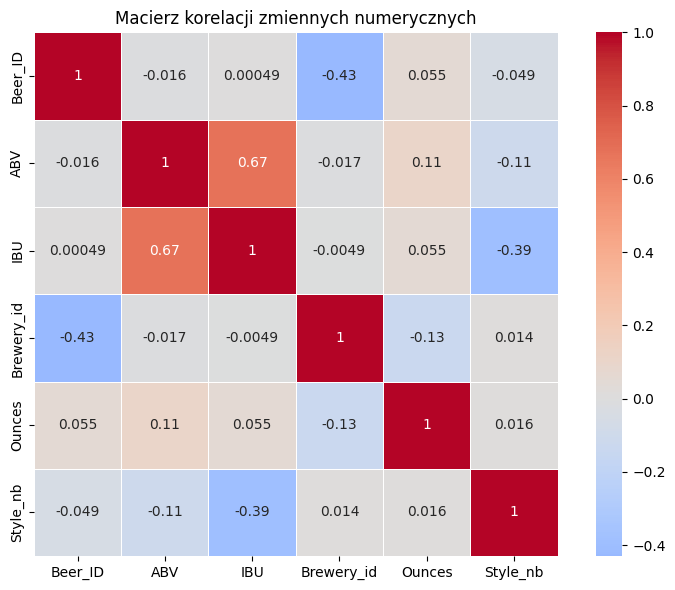

In [56]:
# Macierz korelacji dla zmiennych numerycznych

plt.figure(figsize=(8, 6))
correlation_matrix = df1.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Macierz korelacji zmiennych numerycznych')
plt.tight_layout()
plt.show()

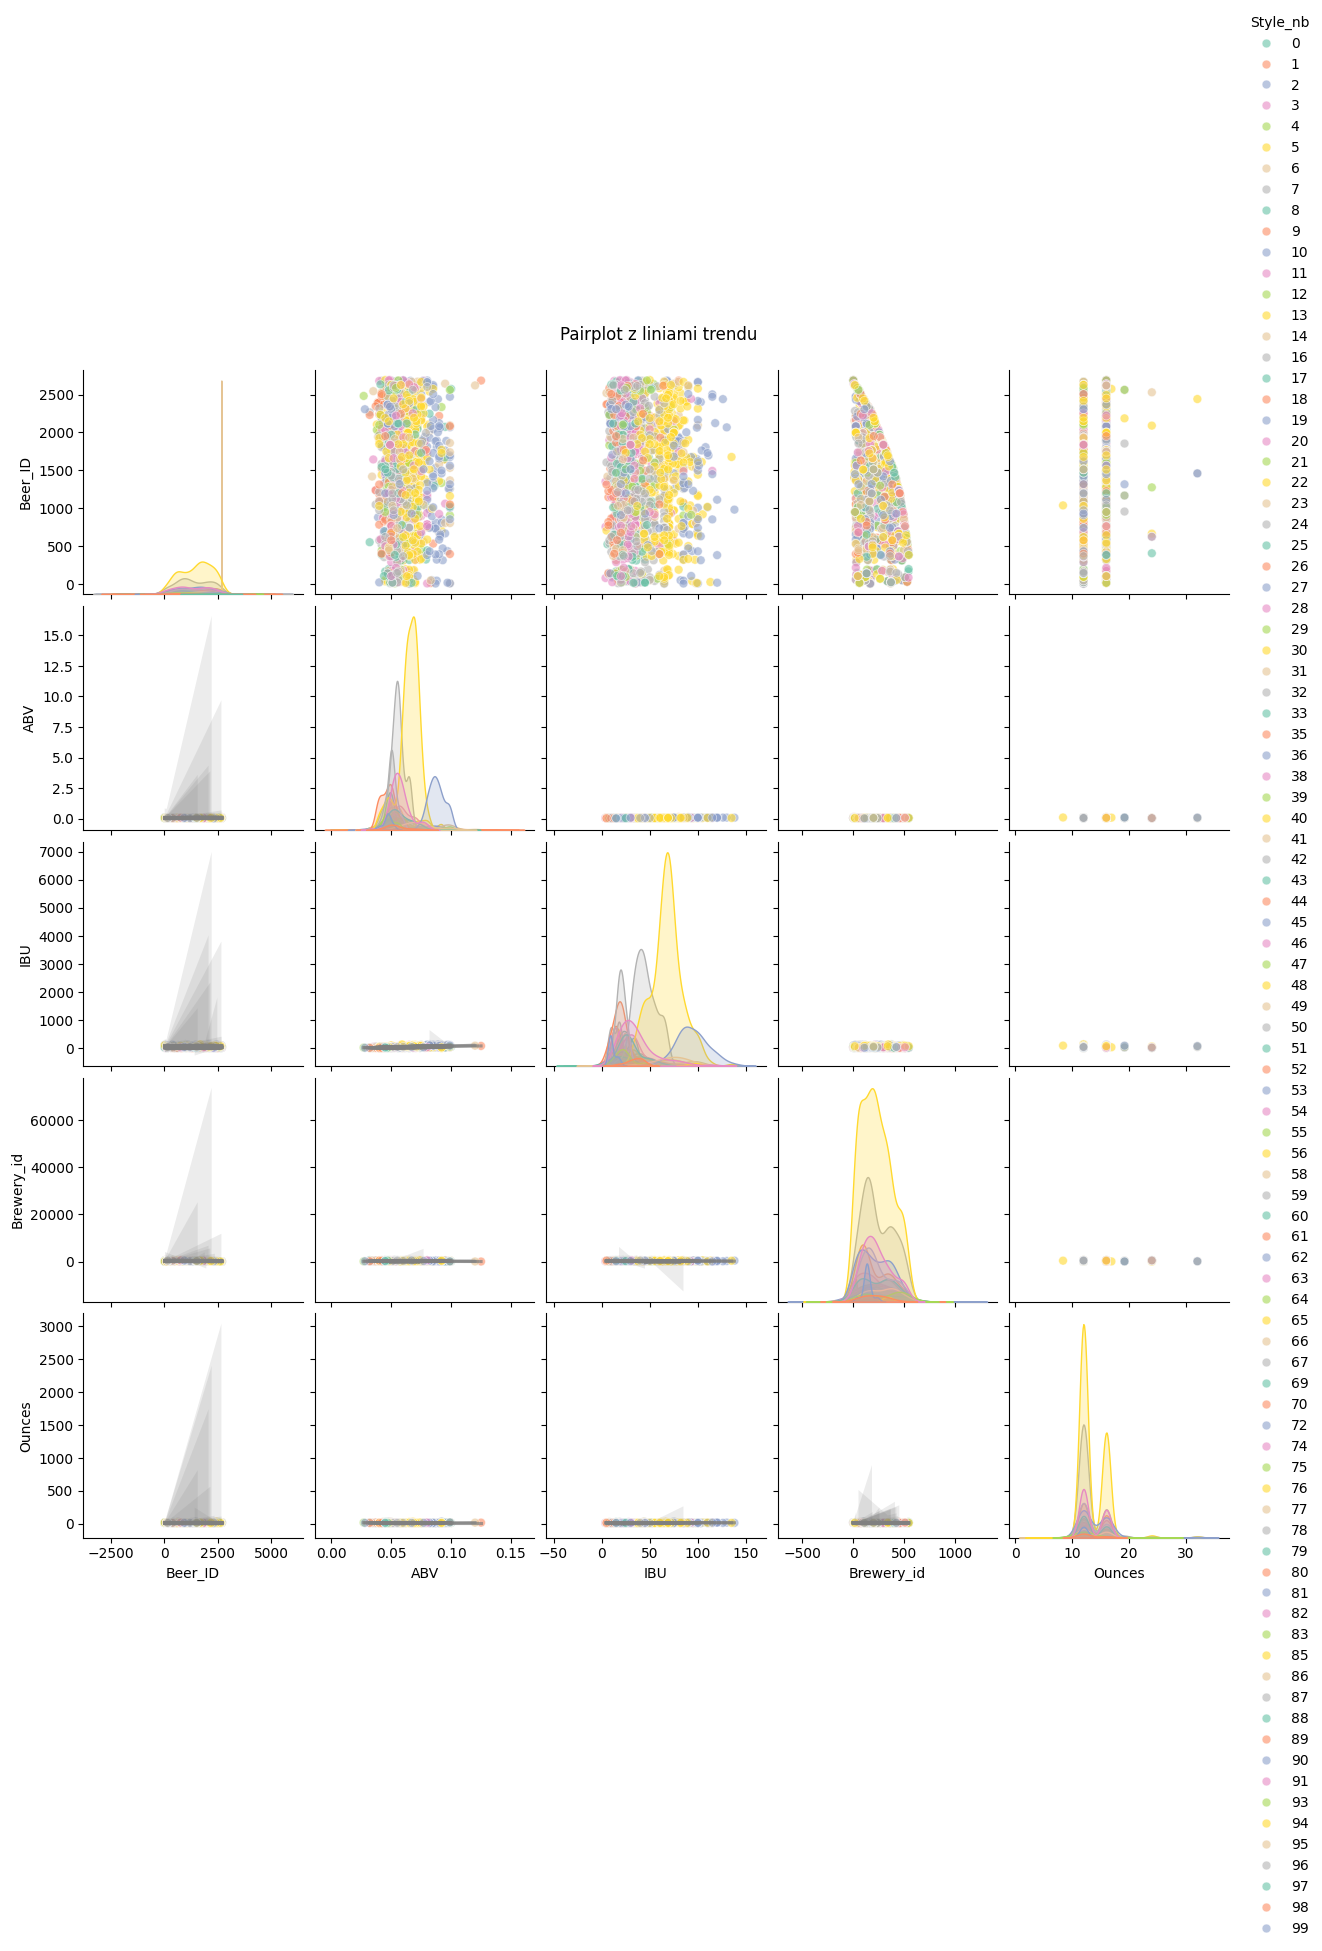

In [60]:
def regression_line(x, y, **kws):
    sns.regplot(x=x, y=y, scatter=False, **kws)

# Pairplot z liniami trendu
g = sns.pairplot(df1, 
                 hue='Style_nb',
                 diag_kind='kde',
                 palette='Set2',
                 plot_kws={'alpha': 0.6, 's': 40},
                 diag_kws={'fill': True})

# Dodajemy linie trendu dla każdej kombinacji
g.map_lower(regression_line, color='gray', line_kws={'alpha': 0.7})
plt.suptitle('Pairplot z liniami trendu', y=1.02)
plt.show()

In [50]:
X = df1.drop(columns=['Ounces', 'Name', 'IBU'])
y = df1['Ounces']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Check for infinite values
print("Infinite values in X:", np.isinf(X).sum())
print("NaN values in X:", np.isnan(X).sum())

# Check for infinite values in y
print("Infinite values in y:", np.isinf(y).sum())
print("NaN values in y:", np.isnan(y).sum())

Infinite values in X: Beer_ID       0
ABV           0
Brewery_id    0
Style_nb      0
dtype: int64
NaN values in X: Beer_ID       0
ABV           0
Brewery_id    0
Style_nb      0
dtype: int64
Infinite values in y: 0
NaN values in y: 0


In [51]:
model = sm.OLS(y_train, X_train).fit()
predictions = model.predict(X_test)

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:                  Ounces   R-squared (uncentered):                   0.948
Model:                             OLS   Adj. R-squared (uncentered):              0.948
Method:                  Least Squares   F-statistic:                              5156.
Date:              niedz., 23 lis 2025   Prob (F-statistic):                        0.00
Time:                         13:42:50   Log-Likelihood:                         -2872.3
No. Observations:                 1124   AIC:                                      5753.
Df Residuals:                     1120   BIC:                                      5773.
Df Model:                            4                                                  
Covariance Type:             nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Beer_ID        0.0017      0.000     14.353      0.000       0.001       0.002
ABV          148.2529      4.179     35.478      0.000     140.054     156.452
Brewery_id     0.0051      0.001      8.294      0.000       0.004       0.006
Style_nb       0.0241      0.003      7.595      0.000       0.018       0.030
==============================================================================
Omnibus:                      186.374   Durbin-Watson:                   2.086
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              744.346
Skew:                           0.741   Prob(JB):                    2.33e-162
Kurtosis:                       6.701   Cond. No.                     7.31e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.31e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [52]:
lm = linear_model.LinearRegression()
model = lm.fit(X_train,y_train)

In [53]:
predictions = lm.predict(X_test)
print(predictions[0:5])

[13.48273977 13.4446403  13.59692944 13.36002263 14.56743175]
